# Прогнозирование подписки на срочный депозит

## Описание задачи

Построить модель классификации, которая предсказывает, согласится ли клиент банка на срочный депозит на основе данных о маркетинговой кампании.

Данные взяты из открытого датасета Bank Marketing (UCI / OpenML).

## Целевая переменная

`y` — бинарный признак:
- 1 — клиент согласился на депозит
- 0 — клиент отказался

## Метрики

- Accuracy, Precision, Recall, F1
- ROC‑AUC, PR‑AUC
- Confusion Matrix

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка и обзор датасета 

- Типы данных — какие колонки числовые, какие категориальные
- Статистика — средние, минимумы, максимумы числовых признаков
- Есть ли пропуски
- Сколько уникальных значений и какие

In [99]:
from sklearn.datasets import fetch_openml

# Загружаем датасет Bank Marketing
bank = fetch_openml('bank-marketing', version=1, as_frame=True, parser='pandas')
df = bank.frame

# Смотрим данные

print("\nТипы данных по колонкам:")
print(df.dtypes)

print("\nСтатистика по числовым колонкам:")
print(df.describe())

print("\nОбщее количество пропусков во всём датасете:")
print(df.isnull().sum().sum())

print("\nУникальные значения в категориальных колонках:")
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Примеры: {df[col].value_counts().head(3).to_dict()}")



Типы данных по колонкам:
V1          int64
V2       category
V3       category
V4       category
V5       category
V6          int64
V7       category
V8       category
V9       category
V10         int64
V11      category
V12         int64
V13         int64
V14         int64
V15         int64
V16      category
Class    category
dtype: object

Статистика по числовым колонкам:
                 V1             V6           V10           V12           V13  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.0000

**Выводы**
- Пропусков нет
- Целевая переменная Class содержит значения '1' и '2' - надо преобразовать в 0 и 1
- В колонках есть значения 'unknown' —  не пропуски, а отдельная категория
- 16 признаков и целевую надо пепреименовать для удобства
- V1 (возраст): от 18 до 95 лет — данные реалистичны
- V6 (баланс) - разброс огромный: от -8019 до 102127. Среднее (1362) значительно выше медианы (448) —  сильные выбросы (клиенты с очень большими балансами)
- V12 (длительность звонка): 75% звонков длятся до 319 секунд, но максимум достигает 4918 секунд — есть сильные выбросы 

## Переименование колонок и преобразование целевой переменной

In [100]:
df.columns = [
    'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
    'loan', 'contact', 'day', 'month', 'duration', 'campaign',
    'pdays', 'previous', 'poutcome', 'y'
]

# Преобразуем целевую переменную: Class содержал '1' и '2'
# В этом датасете '1' = 'no', '2' = 'yes'
df['y'] = (df['y'].astype(str) == '2').astype(int)

print(f"Загружено {len(df)} строк, {len(df.columns)} признаков")
print(df.head(20))
print(df.info())

Загружено 45211 строк, 17 признаков
    age           job   marital  education default  balance housing loan  \
0    58    management   married   tertiary      no     2143     yes   no   
1    44    technician    single  secondary      no       29     yes   no   
2    33  entrepreneur   married  secondary      no        2     yes  yes   
3    47   blue-collar   married    unknown      no     1506     yes   no   
4    33       unknown    single    unknown      no        1      no   no   
5    35    management   married   tertiary      no      231     yes   no   
6    28    management    single   tertiary      no      447     yes  yes   
7    42  entrepreneur  divorced   tertiary     yes        2     yes   no   
8    58       retired   married    primary      no      121     yes   no   
9    43    technician    single  secondary      no      593     yes   no   
10   41        admin.  divorced  secondary      no      270     yes   no   
11   29        admin.    single  secondary      no  

In [101]:
# Целевая переменная %
print("\nЦелевая переменная (y):")
print(df['y'].value_counts())
print(f"   Доля '1' (согласились): {df['y'].mean()*100:.2f}%")

# Где есть unknown
print("\nЗначения 'unknown' в колонках:")
unknown_cols = ['job', 'education', 'contact', 'poutcome']
for col in unknown_cols:
    if col in df.columns:
        count = (df[col] == 'unknown').sum()
        if count > 0:
            print(f"   {col}: {count} ({count/len(df)*100:.1f}%)")



Целевая переменная (y):
y
0    39922
1     5289
Name: count, dtype: int64
   Доля '1' (согласились): 11.70%

Значения 'unknown' в колонках:
   job: 288 (0.6%)
   education: 1857 (4.1%)
   contact: 13020 (28.8%)
   poutcome: 36959 (81.7%)


**Выводы:**
- Доля согласившихся — 11.7% (сильный дисбаланс), Accuracy не подходит, используем ROC‑AUC, F1 и PR‑AUC, устойчивые к дисбалансу
- 'unknown' встречается в contact (28.8%) и poutcome (81.7%) — оставляю как отдельную категорию

## SQL
(для демонстрации)

Сохраняю данные в SQLite и выполняю запросы:
 - Фильтрация (SELECT + WHERE)— выбираю клиентов старше 30 лет, с длительностью звонка более 100 секунд, которые согласились на депозит
 - Группировка (GROUP BY + агрегация) — считаю, сколько согласившихся в каждой профессии и их среднюю длительность звонка
 - Объединение таблиц (LEFT JOIN) — добавляю к профессиям категории (office, manual, business и т.д.), чтобы увидеть, какие сферы активнее



In [102]:
# Сохраняем в SQLite
conn = sqlite3.connect('bank_marketing.db')
df.to_sql('bank_marketing', conn, if_exists='replace', index=False)
conn.close()

# Фильтрация
conn = sqlite3.connect('bank_marketing.db')
query1 = """
SELECT age, job, duration, campaign, y
FROM bank_marketing
WHERE age > 30 AND duration > 100 AND y = 1
LIMIT 5
"""
df_sql1 = pd.read_sql(query1, conn)
conn.close()
print("\nКлиенты > 30 лет, длительность > 100 сек, которые согласились:")
print(df_sql1)

# Группировка
conn = sqlite3.connect('bank_marketing.db')
query2 = """
SELECT 
    job,
    COUNT(*) as count,
    AVG(duration) as avg_duration
FROM bank_marketing
WHERE y = 1
GROUP BY job
ORDER BY count DESC
LIMIT 5
"""
df_sql2 = pd.read_sql(query2, conn)
conn.close()
print("\nТоп-5 профессий среди согласившихся:")
print(df_sql2)

# JOIN
job_categories = pd.DataFrame({
    'job': ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 
            'retired', 'self-employed', 'services', 'student', 'technician', 
            'unemployed', 'unknown'],
    'job_category': ['office', 'manual', 'business', 'manual', 'office',
                     'other', 'business', 'service', 'student', 'technical',
                     'other', 'other']
})

conn = sqlite3.connect('bank_marketing.db')
job_categories.to_sql('job_categories', conn, if_exists='replace', index=False)
conn.close()

conn = sqlite3.connect('bank_marketing.db')
query3 = """
SELECT b.job, j.job_category, COUNT(*) as count
FROM bank_marketing b
LEFT JOIN job_categories j ON b.job = j.job
WHERE b.y = 1
GROUP BY b.job
ORDER BY count DESC
LIMIT 5
"""
df_sql3 = pd.read_sql(query3, conn)
conn.close()
print("\nТоп-5 профессий с категориями:")
print(df_sql3)



Клиенты > 30 лет, длительность > 100 сек, которые согласились:
   age         job  duration  campaign  y
0   59      admin.      1042         1  1
1   56      admin.      1467         1  1
2   41  technician      1389         1  1
3   55    services       579         1  1
4   54      admin.       673         2  1

Топ-5 профессий среди согласившихся:
           job  count  avg_duration
0   management   1301    499.620292
1   technician    840    539.433333
2  blue-collar    708    675.355932
3       admin.    631    503.114105
4      retired    516    460.325581

Топ-5 профессий с категориями:
           job job_category  count
0   management       office   1301
1   technician    technical    840
2  blue-collar       manual    708
3       admin.       office    631
4      retired        other    516


## Исследовательский анализ данных (EDA)
- Распределение целевой переменной
- Топ-10 профессий
- Семейное положение
- Образование


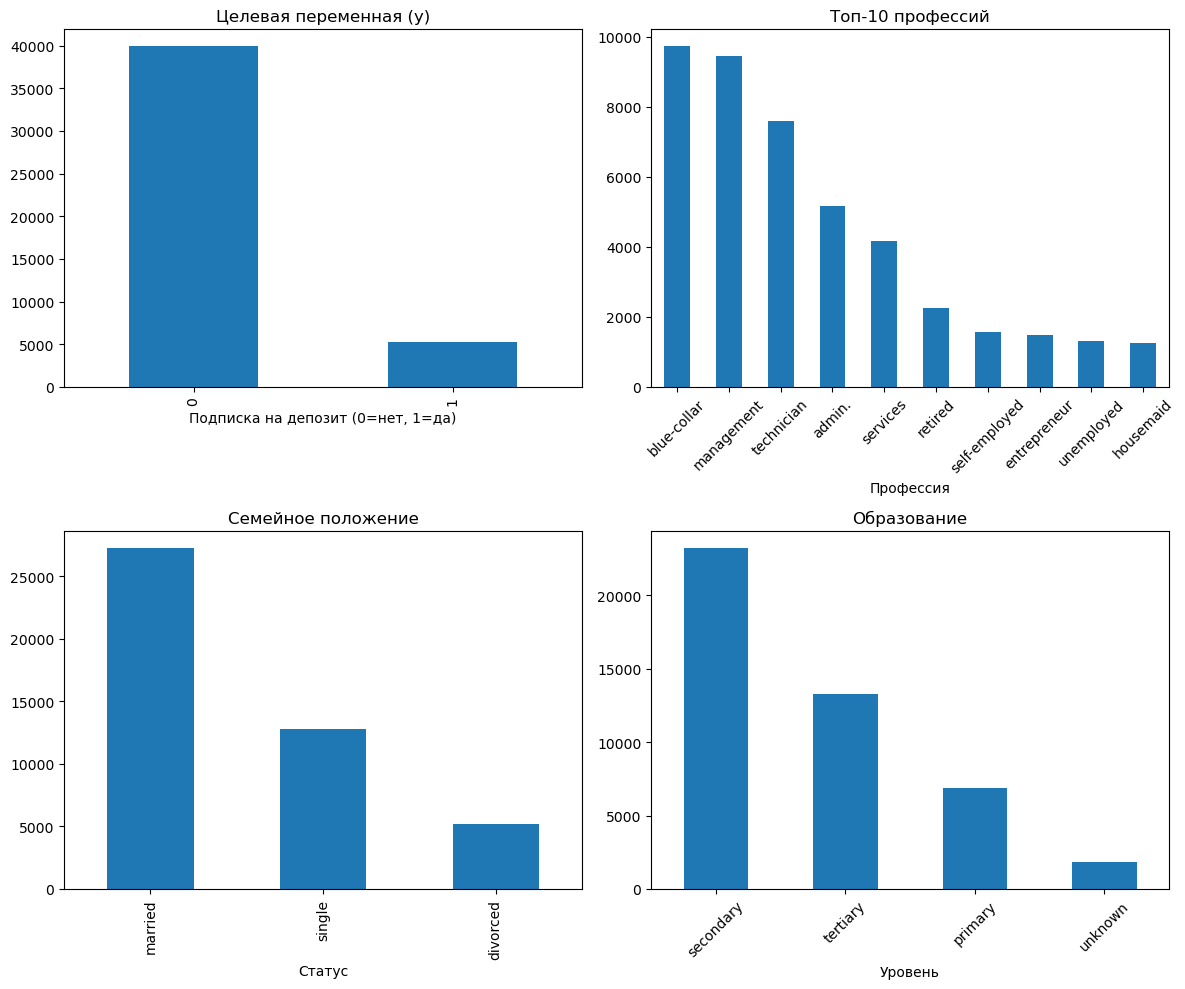

Всего записей: 45211
Согласились на депозит: 5289 (11.70%)

Кто чаще соглашается на депозит?

1. Семейное положение:
marital
single      0.149492
divorced    0.119455
married     0.101235
Name: y, dtype: float64

2. Образование:
education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: y, dtype: float64

3. Топ-5 профессий по доле согласившихся:
job
student       0.286780
retired       0.227915
unemployed    0.155027
management    0.137556
admin.        0.122027
Name: y, dtype: float64


/var/folders/jz/n7_n8znd4q52vk_hlg6phxpm0000gn/T/ipykernel_3533/3749593157.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marital_rate = df.groupby('marital')['y'].mean().sort_values(ascending=False)
/var/folders/jz/n7_n8znd4q52vk_hlg6phxpm0000gn/T/ipykernel_3533/3749593157.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_rate = df.groupby('education')['y'].mean().sort_values(ascending=False)
/var/folders/jz/n7_n8znd4q52vk_hlg6phxpm0000gn/T/ipykernel_3533/3749593157.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

In [103]:
# Преобраз duration в число 
df['duration'] = df['duration'].astype(float)

# Cетка 2x2 для четырёх графиков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Столбчатая диарамма для целевой переменной
df['y'].value_counts().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Целевая переменная (y)')
axes[0, 0].set_xlabel('Подписка на депозит (0=нет, 1=да)')

# Топ-10 профессий
df['job'].value_counts().head(10).plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Топ-10 профессий')
axes[0, 1].set_xlabel('Профессия')
axes[0, 1].tick_params(axis='x', rotation=45)

# Семейное положение клиентов
df['marital'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Семейное положение')
axes[1, 0].set_xlabel('Статус')

# Образование
df['education'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Образование')
axes[1, 1].set_xlabel('Уровень')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Общая статистика по целевой переменной
print(f"Всего записей: {len(df)}")
print(f"Согласились на депозит: {df['y'].sum()} ({df['y'].mean()*100:.2f}%)")

print("\nКто чаще соглашается на депозит?")

print("\n1. Семейное положение:")
marital_rate = df.groupby('marital')['y'].mean().sort_values(ascending=False)
print(marital_rate)

print("\n2. Образование:")
education_rate = df.groupby('education')['y'].mean().sort_values(ascending=False)
print(education_rate)

print("\n3. Топ-5 профессий по доле согласившихся:")
job_rate = df.groupby('job')['y'].mean().sort_values(ascending=False).head(5)
print(job_rate)

**Выводы:** 
- Классов мало (~11.7%), Accuracy не подходит, используем ROC‑AUC, F1 и PR‑AUC, устойчивые к дисбалансу
- Самые частые профессии : `blue-collar`, `management`, `technician`
- Большинство клиентов женаты/замужем (`married`), имеют среднее образование (`secondary`)
- Cтуденты, пенсионеры, люди с высшим образованием и одинокие чаще соглашаются на депозит

## Feature Engineering
Новые признаки:
- `job_length` — длина названия профессии (чем длиннее, тем более специфичная профессия)
- `education_length` — длина названия образования (возможно, длина названия коррелирует с уровнем образования)
- `age_group` — возрастные группы (young, middle, senior, elderly)

In [104]:
df['job_length'] = df['job'].astype(str).str.len()

df['education_length'] = df['education'].astype(str).str.len()

df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 25, 35, 50, 65, 100], 
                         labels=['young', 'young_middle', 'middle', 'senior', 'elderly'])

print(df[['age', 'age_group', 'job_length', 'education_length']].head())

   age     age_group  job_length  education_length
0   58        senior          10                 8
1   44        middle          10                 9
2   33  young_middle          12                 9
3   47        middle          11                 7
4   33  young_middle           7                 7


## Подготовка данных к обучению

- **Числовые признаки:** масштабирование (StandardScaler)
- **Категориальные признаки:** OneHotEncoder
- **Разделение:** 80% — обучение, 20% — тест
- **Pipeline:** объединяет препроцессор и модель

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Колонки
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                    'contact', 'month', 'poutcome', 'age_group']
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays',
                'previous', 'job_length', 'education_length']

X = df[categorical_cols + numeric_cols]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Препроцессор
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


## Обучение моделей

Сравниваю 5 моделей:
- Logistic Regression
- k‑NN (с подбором гиперпараметров)
- Random Forest
- LightGBM
- CatBoost

**Метрики:** Accuracy, Precision, Recall, F1, ROC‑AUC, PR‑AUC
- Аccuracy — доля всех правильных ответов
- Precision — из всех, кого модель назвала согласившимися, сколько действительно согласились
- Recall — из всех реальных согласившихся, сколько модель нашла
- ROC‑AUC - насколько хорошо модель разделяет классы (0 и 1) при всех возможных порогах
- PR‑AUC) - насколько хорошо модель находит редкий класс(согласившихся) и не ошибается с ложными срабатываниями
- F1 (гармоническое среднее Precision и Recall) - баланс между точностью и полнотой, помогает выбрать оптимальный порог классификации

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

from sklearn.metrics import precision_recall_curve, average_precision_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=100, random_seed=42, verbose=False)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

print("\nСравнение моделей")
print(pd.DataFrame(results).T.round(4))

#PR-AUC (Average Precision) 

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

print(f"PR-AUC (Average Precision): {ap_score:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Сравнение моделей
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8983     0.6492  0.3410  0.4471   0.9054
k-NN (k=5)             0.8958     0.6305  0.3300  0.4332   0.8338
Random Forest          0.9028     0.6661  0.3896  0.4916   0.9221
LightGBM               0.9078     0.6546  0.4986  0.5661   0.9341
CatBoost               0.9088     0.6539  0.5179  0.5780   0.9334
PR-AUC (Average Precision): 0.6328


## Выводы по результатам обучения
Лучшая модель:CatBoost

Потому что эта модель показала лучший баланс между всеми метриками:
- ROC‑AUC = 0.9334 — модель отлично разделяет классы (ближе к 1)
- PR‑AUC = 0.63 — модель неплохо находит редкий класс согласившихся
- F1 = 0.578 — лучший баланс между точностью и полнотой
- Recall = 0.518 — нашёл 52% всех реальных согласившихся

- Из 100 клиентов, которых модель назвала "целевыми", 65 реально согласятся на депозит (Precision = 65%)
- Модель находит 52 из 100 реальных согласившихся (Recall = 52%)
- Это позволяет сократить затраты на бесполезные звонки и эффективно использовать ресурсы

Итог: CatBoost — лучшая модель для предсказания согласия на депозит

## ROC-кривая
ROC-кривая показывает, как модель разделяет классы при разных порогах:

- **По оси X** — доля ложных срабатываний (FPR): сколько отказников мы ошибочно назвали согласившимися
- **По оси Y** — доля верных срабатываний (TPR): сколько реальных согласившихся мы нашли


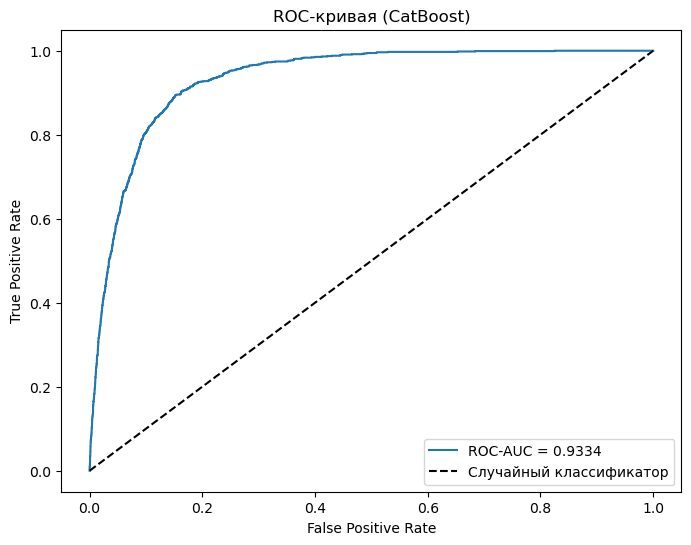

In [110]:
from sklearn.metrics import roc_curve

best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(iterations=100, random_seed=42, verbose=False))
])
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (CatBoost)')
plt.legend()
plt.show()

- AUC = 0.93 — отличный результат,чем ближе AUC к 1, тем лучше модель отличает согласившихся от отказавшихся
- Кривая уходит в левый верхний угол — модель хорошо отличает согласившихся от отказавшихся


## Confusion Matrix

Матрица ошибок для лучшей модели (CatBoost)
- True Negatives (TN) — правильно предсказали отказ (0 → 0)
- False Positives (FP) — ошибочно предсказали согласие (0 → 1)
- False Negatives (FN) — пропустили согласившегося (1 → 0)
- True Positives (TP) — правильно нашли согласившегося (1 → 1)

Помогает понять, на каких ошибках модель "спотыкается" — пропускает клиентов (FN) или ошибочно звонит отказникам (FP)

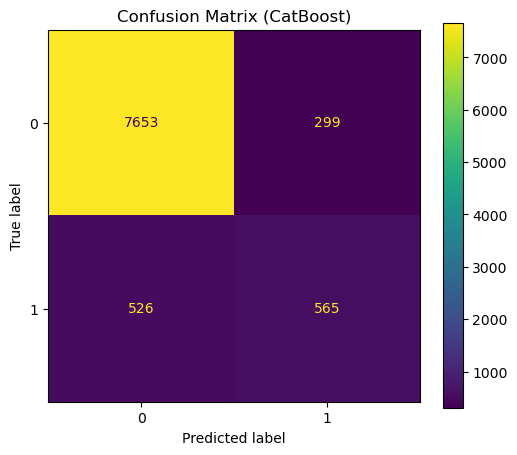

In [112]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix (CatBoost)')
plt.show()


- **7653** — правильно предсказали отказы
- **565** — ошибочно предсказали согласие
- **526** — пропустили согласившихся
- **299** — правильно нашли согласившихся